In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Mount your Google Drive to access your files
from google.colab import drive
drive.mount('/content/drive')

print("✅ Step 1 Complete: Drive mounted and libraries imported.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Step 1 Complete: Drive mounted and libraries imported.


# **T**-**loop**

In [ ]:
# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/t_loop_ujire_final.xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 't' classification
label_columns = ['T_loop', 'T_not_loop']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 't' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 't'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 't', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 't' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
T_not_loop    2210
T_loop         639
Name: count, dtype: int64

Scanning for all 't' images in your Drive... (this may take a moment)
Found 9313 total 't' images.

Successfully created a final, clean dataset with 2849 labeled images.

Here's a sample of the final data:
                      filename   label  \
0  IMG-20250415-WA0003_210.png  T_loop   
1  IMG-20250415-WA0003_217.png  T_loop   
2  IMG-20250415-WA0003_228.png  T_loop   
3  IMG-20250415-WA0003_230.png  T_loop   
4  IMG-20250415-WA0003_237.png  T_loop   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
1  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
2  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
3  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
4  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  

✅ Step 2 Complete: Data is loaded and prep

In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 2849
Training samples:   1994
Validation samples: 427
Testing samples:    428

--- Label Distribution Check ---

Training Set:
label
T_not_loop    0.775827
T_loop        0.224173
Name: proportion, dtype: float64

Validation Set:
label
T_not_loop    0.775176
T_loop        0.224824
Name: proportion, dtype: float64

Testing Set:
label
T_not_loop    0.775701
T_loop        0.224299
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 1994 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 427 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 428 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: T_loop).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_tloop_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(2.2304250559284116), np.int64(1): np.float64(0.6444731738849386)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: T_loop).

--- Starting Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 26s/step - accuracy: 0.4115 - loss: 0.6981 
Epoch 1: val_accuracy improved from -inf to 0.54333, saving model to /content/drive/MyDrive/Modelsss/best_tloop_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 2026s 32s/step - accuracy: 0.4111 - loss: 0.6980 - val_accuracy: 0.5433 - val_loss: 0.7027
Epoch 2/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.5839 - loss: 0.6764
Epoch 2: val_accuracy improved from 0.54333 to 0.69555, saving model to /content/drive/MyDrive/Modelsss/best_tloop_model.keras
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 149ms/step - accuracy: 0.5837 - loss: 0.6766 - val_accuracy: 0.6956 - val_loss: 0.6420
Epoch 3/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.6438 - loss: 0.6586
Epoch 3: val_accuracy did not improve from 0.69555
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.6430 - loss: 0.6587 - val_accuracy: 0.3794 - val_loss: 0.7808
Epoch 4/50
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.6045 - loss: 0.6517
Ep

--- Final Evaluation ---


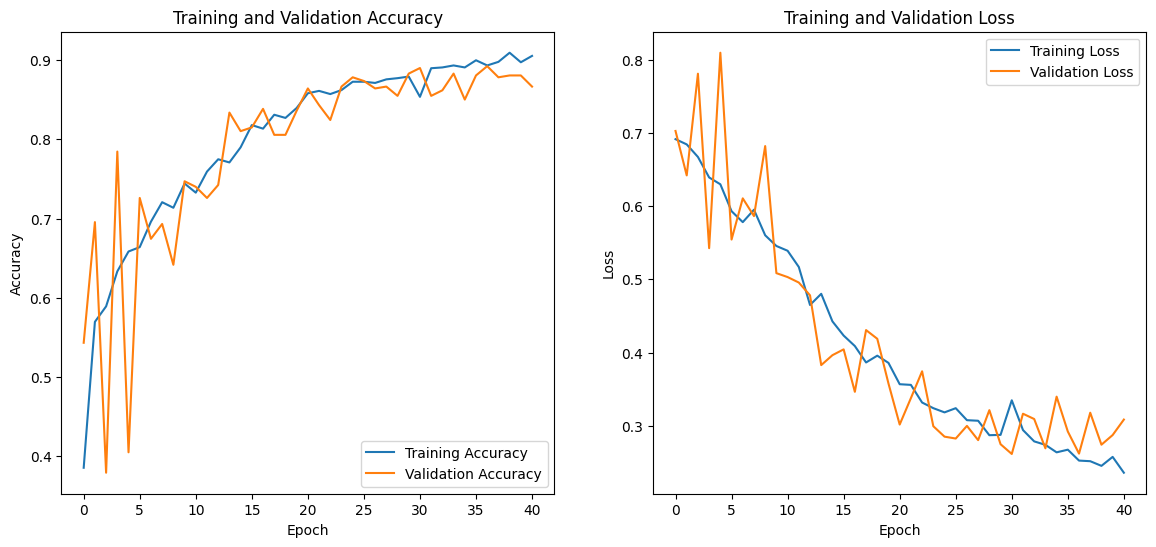


--- Evaluating on Test Data ---
14/14 ━━━━━━━━━━━━━━━━━━━━ 306s 23s/step - accuracy: 0.9139 - loss: 0.2088
Final Test Accuracy: 89.95%
Final Test Loss: 0.2468

--- Detailed Performance Analysis ---
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step

Classification Report:
              precision    recall  f1-score   support

      T_loop       0.81      0.72      0.76        96
  T_not_loop       0.92      0.95      0.94       332

    accuracy                           0.90       428
   macro avg       0.87      0.84      0.85       428
weighted avg       0.90      0.90      0.90       428


Confusion Matrix:


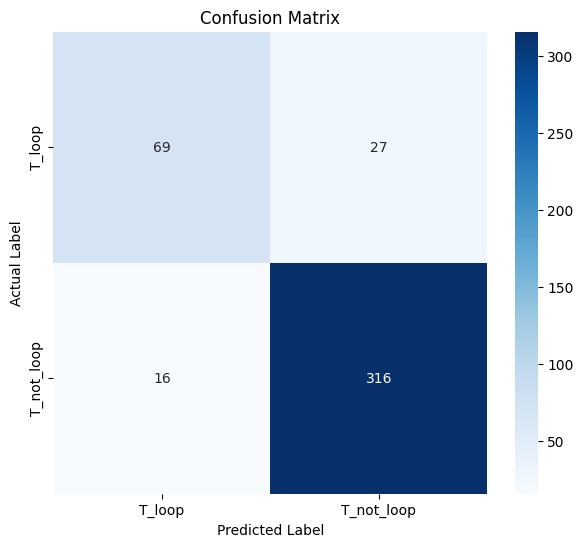


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_tloop_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")

# **G_LOOP**

In [ ]:
# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/G_LOOP_UJIRE.xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 'g' classification
label_columns = ['g-loop', 'g-no-loop']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 'g' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 'g'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 'g', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 'g' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
g-loop       566
g-no-loop    345
Name: count, dtype: int64

Scanning for all 'g' images in your Drive... (this may take a moment)
Found 3201 total 'g' images.

Successfully created a final, clean dataset with 911 labeled images.

Here's a sample of the final data:
                      filename   label  \
0  IMG-20250415-WA0003_177.png  g-loop   
1  IMG-20250415-WA0003_187.png  g-loop   
2  IMG-20250415-WA0003_183.png  g-loop   
3  IMG-20250415-WA0003_192.png  g-loop   
4  IMG-20250415-WA0003_202.png  g-loop   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/s-2021/g...  
1  /content/drive/MyDrive/extract1_FINAL/s-2021/g...  
2  /content/drive/MyDrive/extract1_FINAL/s-2021/g...  
3  /content/drive/MyDrive/extract1_FINAL/s-2021/g...  
4  /content/drive/MyDrive/extract1_FINAL/s-2021/g...  

✅ Step 2 Complete: Data is loaded and prepared.

In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 911
Training samples:   637
Validation samples: 137
Testing samples:    137

--- Label Distribution Check ---

Training Set:
label
g-loop       0.621664
g-no-loop    0.378336
Name: proportion, dtype: float64

Validation Set:
label
g-loop       0.620438
g-no-loop    0.379562
Name: proportion, dtype: float64

Testing Set:
label
g-loop       0.620438
g-no-loop    0.379562
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 637 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 137 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 137 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: g-loop).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_gloop_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(0.8042929292929293), np.int64(1): np.float64(1.3215767634854771)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: g-loop).

--- Starting Training ---
Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7378 - loss: 0.5804
Epoch 1: val_accuracy improved from -inf to 0.72993, saving model to /content/drive/MyDrive/Modelsss/best_gloop_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7368 - loss: 0.5801 - val_accuracy: 0.7299 - val_loss: 0.5382
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6594 - loss: 0.5716
Epoch 2: val_accuracy improved from 0.72993 to 0.77372, saving model to /content/drive/MyDrive/Modelsss/best_gloop_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6620 - loss: 0.5704 - val_accuracy: 0.7737 - val_loss: 0.4462
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7154 - loss: 0.5449
Epoch 3: val_accuracy 

--- Final Evaluation ---


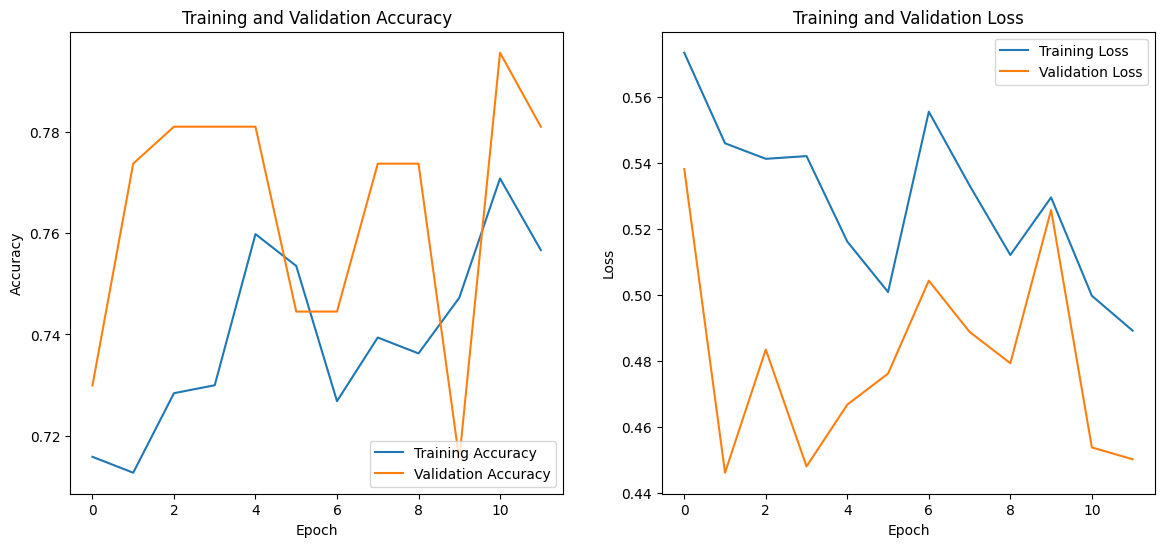


--- Evaluating on Test Data ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.7880 - loss: 0.4474
Final Test Accuracy: 80.29%
Final Test Loss: 0.4336

--- Detailed Performance Analysis ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step

Classification Report:
              precision    recall  f1-score   support

      g-loop       0.85      0.82      0.84        85
   g-no-loop       0.73      0.77      0.75        52

    accuracy                           0.80       137
   macro avg       0.79      0.80      0.79       137
weighted avg       0.81      0.80      0.80       137


Confusion Matrix:


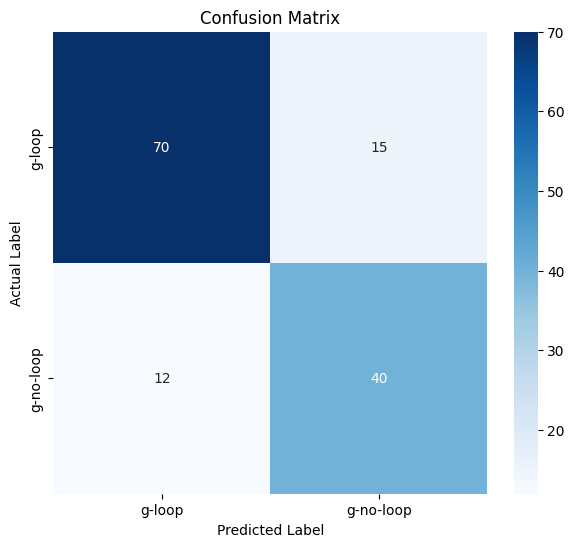


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_gloop_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")

# **T-Mirrored**

In [ ]:
# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/ujire_t_mirrorred.xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 't' classification
label_columns = ['t_non_mirrored', 't_mirrored']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 't' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 't'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 't', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 't' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
t_non_mirrored    608
t_mirrored        465
Name: count, dtype: int64

Scanning for all 't' images in your Drive... (this may take a moment)
Found 9313 total 't' images.

⚠️ Warning: Could not find 2 files listed in your Excel sheet.
This can happen if filenames in the Excel sheet don't exactly match the image filenames.

Successfully created a final, clean dataset with 1071 labeled images.

Here's a sample of the final data:
                      filename           label  \
0  IMG-20250415-WA0003_181.png  t_non_mirrored   
1  IMG-20250415-WA0003_191.png  t_non_mirrored   
2  IMG-20250415-WA0003_199.png  t_non_mirrored   
3  IMG-20250415-WA0003_213.png  t_non_mirrored   
4  IMG-20250415-WA0003_227.png  t_non_mirrored   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
1  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
2

In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 1071
Training samples:   749
Validation samples: 161
Testing samples:    161

--- Label Distribution Check ---

Training Set:
label
t_non_mirrored    0.567423
t_mirrored        0.432577
Name: proportion, dtype: float64

Validation Set:
label
t_non_mirrored    0.565217
t_mirrored        0.434783
Name: proportion, dtype: float64

Testing Set:
label
t_non_mirrored    0.565217
t_mirrored        0.434783
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 749 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 161 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 161 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: t-mirrored).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_t_mirrored_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(1.1558641975308641), np.int64(1): np.float64(0.8811764705882353)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: t-mirrored).

--- Starting Training ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 959ms/step - accuracy: 0.4755 - loss: 0.6954
Epoch 1: val_accuracy improved from -inf to 0.56522, saving model to /content/drive/MyDrive/Modelsss/best_t_mirrored_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4762 - loss: 0.6953 - val_accuracy: 0.5652 - val_loss: 0.6929
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5320 - loss: 0.6930
Epoch 2: val_accuracy did not improve from 0.56522
24/24 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5314 - loss: 0.6930 - val_accuracy: 0.4348 - val_loss: 0.6953
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4451 - loss: 0.6921
Epoch 3: val_accuracy did not improve from 0.56522
24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/s

--- Final Evaluation ---


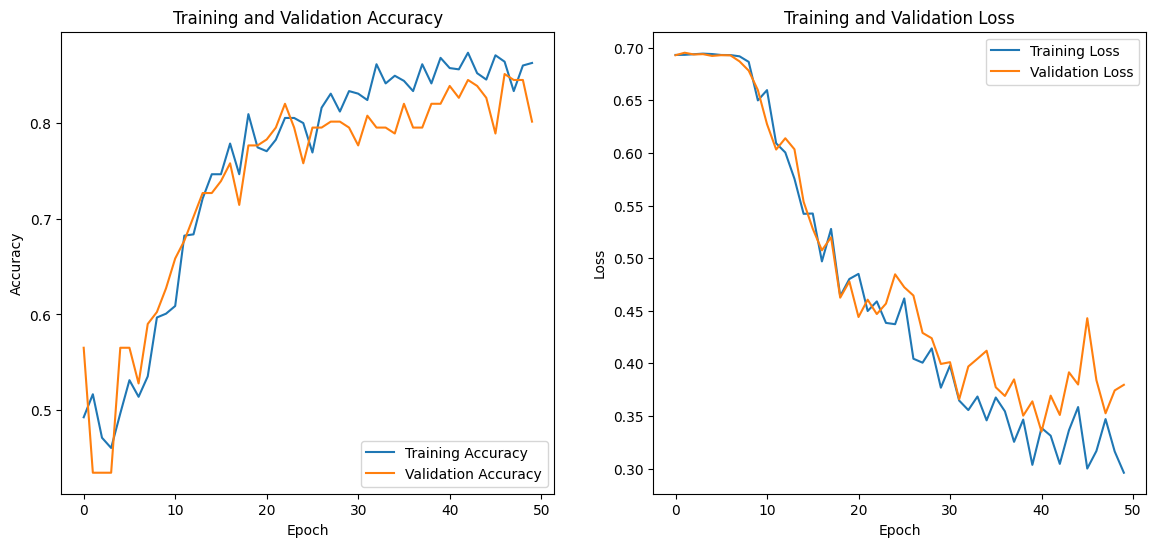


--- Evaluating on Test Data ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 456ms/step - accuracy: 0.8775 - loss: 0.2879
Final Test Accuracy: 87.58%
Final Test Loss: 0.3020

--- Detailed Performance Analysis ---


6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 257ms/step

Classification Report:
                precision    recall  f1-score   support

    t_mirrored       0.86      0.86      0.86        70
t_non_mirrored       0.89      0.89      0.89        91

      accuracy                           0.88       161
     macro avg       0.87      0.87      0.87       161
  weighted avg       0.88      0.88      0.88       161


Confusion Matrix:


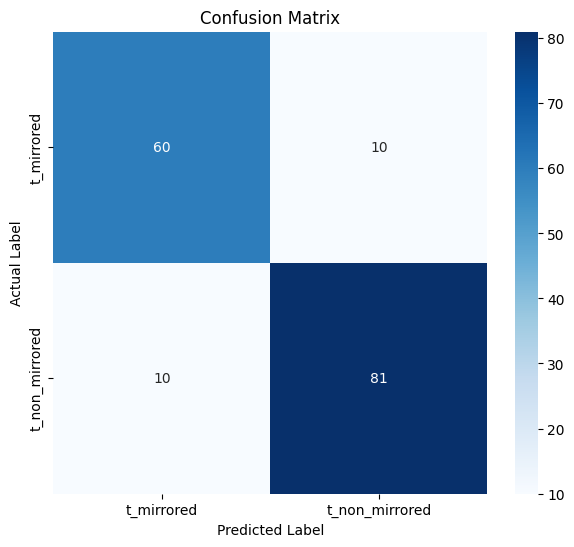


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_t_mirrored_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")

# **D-loop**

In [ ]:
# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/d(loop)_UJIRE_images(1).xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 'd' classification
label_columns = ['d_no_wide_wide', 'd_wide_head']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 'd' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 'g'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 'd', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 'd' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
d_no_wide_wide    966
d_wide_head       131
Name: count, dtype: int64

Scanning for all 'd' images in your Drive... (this may take a moment)
Found 3636 total 'd' images.

Successfully created a final, clean dataset with 1097 labeled images.

Here's a sample of the final data:
                      filename           label  \
0  IMG-20250415-WA0003_194.png  d_no_wide_wide   
1  IMG-20250415-WA0003_208.png  d_no_wide_wide   
2  IMG-20250415-WA0003_222.png  d_no_wide_wide   
3  IMG-20250415-WA0003_241.png  d_no_wide_wide   
4  IMG-20250415-WA0003_246.png  d_no_wide_wide   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
1  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
2  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
3  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
4  /content/drive/MyDrive/extract1_FINAL/s-2

In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 1097
Training samples:   767
Validation samples: 165
Testing samples:    165

--- Label Distribution Check ---

Training Set:
label
d_no_wide_wide    0.880052
d_wide_head       0.119948
Name: proportion, dtype: float64

Validation Set:
label
d_no_wide_wide    0.878788
d_wide_head       0.121212
Name: proportion, dtype: float64

Testing Set:
label
d_no_wide_wide    0.884848
d_wide_head       0.115152
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 767 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 165 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 165 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: d-loop).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_dloop_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(0.5681481481481482), np.int64(1): np.float64(4.168478260869565)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: d-loop).

--- Starting Training ---
Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5818 - loss: 0.7480

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_accuracy improved from -inf to 0.12121, saving model to /content/drive/MyDrive/Modelsss/best_dloop_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 229s 9s/step - accuracy: 0.5820 - loss: 0.7467 - val_accuracy: 0.1212 - val_loss: 0.6993
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3334 - loss: 0.6749
Epoch 2: val_accuracy improved from 0.12121 to 0.13333, saving model to /content/drive/MyDrive/Modelsss/best_dloop_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.3348 - loss: 0.6756 - val_accuracy: 0.1333 - val_loss: 0.7075
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4705 - loss: 0.6784
Epoch 3: val_accuracy improved from 0.13333 to 0.61818, saving model to /content/drive/MyDrive/Modelsss/best_dloop_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.4774 - loss: 0.6788 - val_accuracy: 0.6182 - val_loss: 0.6537
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 935ms/step - accuracy: 0.6301 - loss: 0.6984
Epoch 4: val_accuracy i

--- Final Evaluation ---


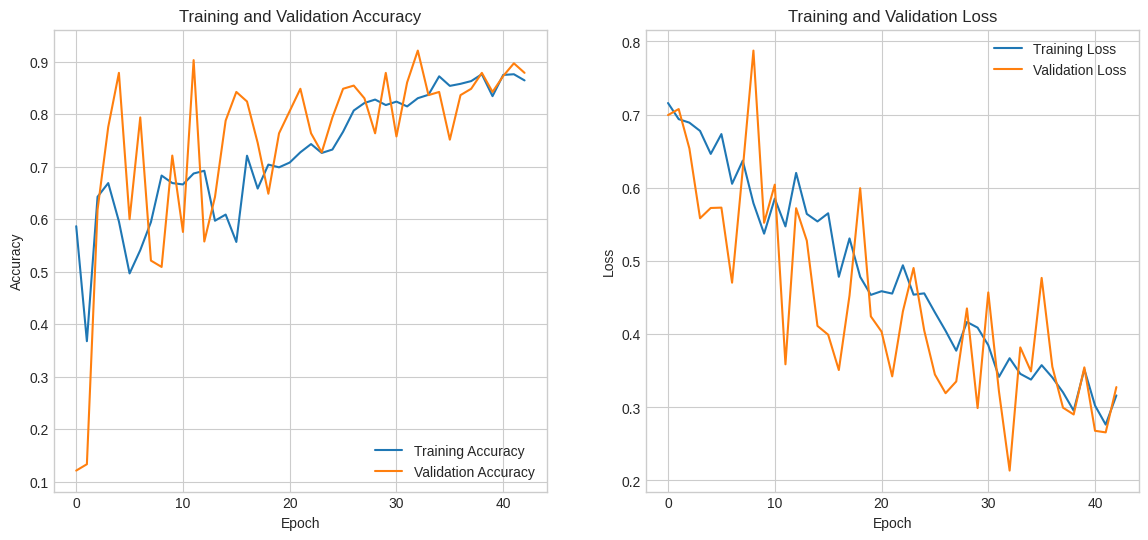


--- Evaluating on Test Data ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.9489 - loss: 0.2516
Final Test Accuracy: 94.55%
Final Test Loss: 0.2704

--- Detailed Performance Analysis ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step

Classification Report:
                precision    recall  f1-score   support

d_no_wide_wide       0.97      0.97      0.97       146
   d_wide_head       0.75      0.79      0.77        19

      accuracy                           0.95       165
     macro avg       0.86      0.88      0.87       165
  weighted avg       0.95      0.95      0.95       165


Confusion Matrix:


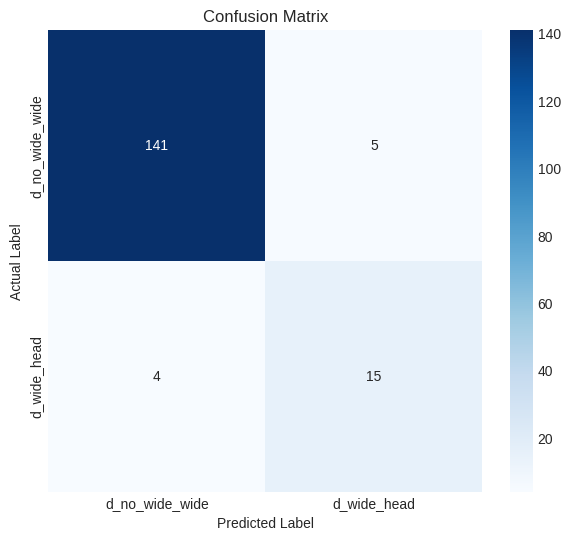


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_dloop_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")

# **E looking like C**

In [ ]:
# Cell 1
from google.colab import drive
import os

print("Connecting to Google Drive...")
drive.mount('/content/drive')
print("✅ Drive connected!")

# --------------------------------------------------------------------------
# ⚠️ ACTION REQUIRED: Define the paths to your files below!
# --------------------------------------------------------------------------

# 1. This is the path to the folder that contains all your patient folders (e.g., 's-2021', 'h-2007').
#    I have filled this based on your previous error logs. Please confirm it is correct.
base_data_path = '/content/drive/MyDrive/extract1_FINAL'

# 2. This is the full path to your Excel file.
excel_file_path = '/content/drive/MyDrive/patient_e_images.xlsx'

# --------------------------------------------------------------------------

# Verify that the paths exist
if os.path.exists(base_data_path):
    print(f"✅ Base data path found: {base_data_path}")
else:
    print(f"❌ ERROR: Base data path NOT found. Please check the path.")

if os.path.exists(excel_file_path):
    print(f"✅ Excel file path found: {excel_file_path}")
else:
    print(f"❌ ERROR: Excel file NOT found. Please check the path.")

Connecting to Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Drive connected!
✅ Base data path found: /content/drive/MyDrive/extract1_FINAL
✅ Excel file path found: /content/drive/MyDrive/patient_e_images.xlsx


In [ ]:
## This is the final and definitive Step 2
import pandas as pd
import os
from tqdm.notebook import tqdm

print("Loading and cleaning data from Excel file...")

# Define the names of your columns
normal_e_column = 'e'
c_like_e_column = 'e looks like c'

# Define the labels we will use (0 for normal, 1 for c-like)
label_map = {
    normal_e_column: 0,
    c_like_e_column: 1
}

# This list will hold paths constructed from the Excel file
unverified_image_data = []
try:
    df = pd.read_excel(excel_file_path)
    # Go through each row of the Excel file
    for index, row in df.iterrows():
        pid = row['PID']
        # Process the 'normal e' column
        if pd.notna(row[normal_e_column]):
            clean_filename = str(row[normal_e_column]).strip()
            if clean_filename:
                full_path = os.path.join(base_data_path, pid, 'e', clean_filename)
                unverified_image_data.append((full_path, label_map[normal_e_column]))

        # Process the 'e looks like c' column
        if pd.notna(row[c_like_e_column]):
            clean_filename = str(row[c_like_e_column]).strip()
            if clean_filename:
                full_path = os.path.join(base_data_path, pid, 'e', clean_filename)
                unverified_image_data.append((full_path, label_map[c_like_e_column]))

    print(f"Found {len(unverified_image_data)} total entries in the Excel file.")

except Exception as e:
    print(f"❌ An error occurred: {e}")

# --------------------------------------------------------------------------
# NEW: Verify that every file in the list actually exists in Google Drive
# --------------------------------------------------------------------------
print("\nVerifying that all files exist in Google Drive (this may take a moment)...")
image_data = [] # This will be our final, clean list
for path, label in tqdm(unverified_image_data):
    if os.path.exists(path):
        image_data.append((path, label))

print(f"\n✅ Verification complete.")
print(f"Kept {len(image_data)} existing files out of {len(unverified_image_data)} total entries.")

Loading and cleaning data from Excel file...
Found 2835 total entries in the Excel file.

Verifying that all files exist in Google Drive (this may take a moment)...


  0%|          | 0/2835 [00:00<?, ?it/s]


✅ Verification complete.
Kept 2832 existing files out of 2835 total entries.


In [ ]:
# Cell 3
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image

# Split the data
labels = [item[1] for item in image_data]
train_list, temp_list = train_test_split(image_data, test_size=0.2, random_state=42, stratify=labels)
val_list, test_list = train_test_split(temp_list, test_size=0.5, random_state=42, stratify=[item[1] for item in temp_list])

print(f"Data split successfully:")
print(f"  Training samples:   {len(train_list)}")
print(f"  Validation samples: {len(val_list)}")
print(f"  Test samples:       {len(test_list)}")

# Define image transformations
image_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Define the custom Dataset class
class HandwritingDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        img_path, label = self.data_list[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

# Create Datasets and DataLoaders
train_dataset = HandwritingDataset(train_list, transform=image_transforms)
val_dataset = HandwritingDataset(val_list, transform=image_transforms)
test_dataset = HandwritingDataset(test_list, transform=image_transforms)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n✅ PyTorch DataLoaders created successfully.")

Data split successfully:
  Training samples:   2265
  Validation samples: 283
  Test samples:       284

✅ PyTorch DataLoaders created successfully.


Calculating class weights...
Data counts in training set: Counter({0: 1705, 1: 560})
Calculated weights (for class 0 and 1): [0.6642228960990906, 2.0223214626312256]

🚀 Starting training on CPU...


Epoch 1/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 0.6966, Train Acc: 0.6278 | Val Loss: 0.6841, Val Acc: 0.6290
✨ Val loss improved. Saving best model...


Epoch 2/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss: 0.6474, Train Acc: 0.6728 | Val Loss: 0.6483, Val Acc: 0.7032
✨ Val loss improved. Saving best model...


...

Epoch 13/50 | Train Loss: 0.1542, Train Acc: 0.9333 | Val Loss: 0.7950, Val Acc: 0.7633
Val loss did not improve. Patience: 8/10


Epoch 14/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 14/50 | Train Loss: 0.1214, Train Acc: 0.9598 | Val Loss: 0.8337, Val Acc: 0.7668
Val loss did not improve. Patience: 9/10


Epoch 15/50 [Train]:   0%|          | 0/71 [00:00<?, ?it/s]

Epoch 15/50 | Train Loss: 0.1039, Train Acc: 0.9656 | Val Loss: 0.8686, Val Acc: 0.7739
Val loss did not improve. Patience: 10/10

🛑 Early stopping triggered.

✅ Training complete!


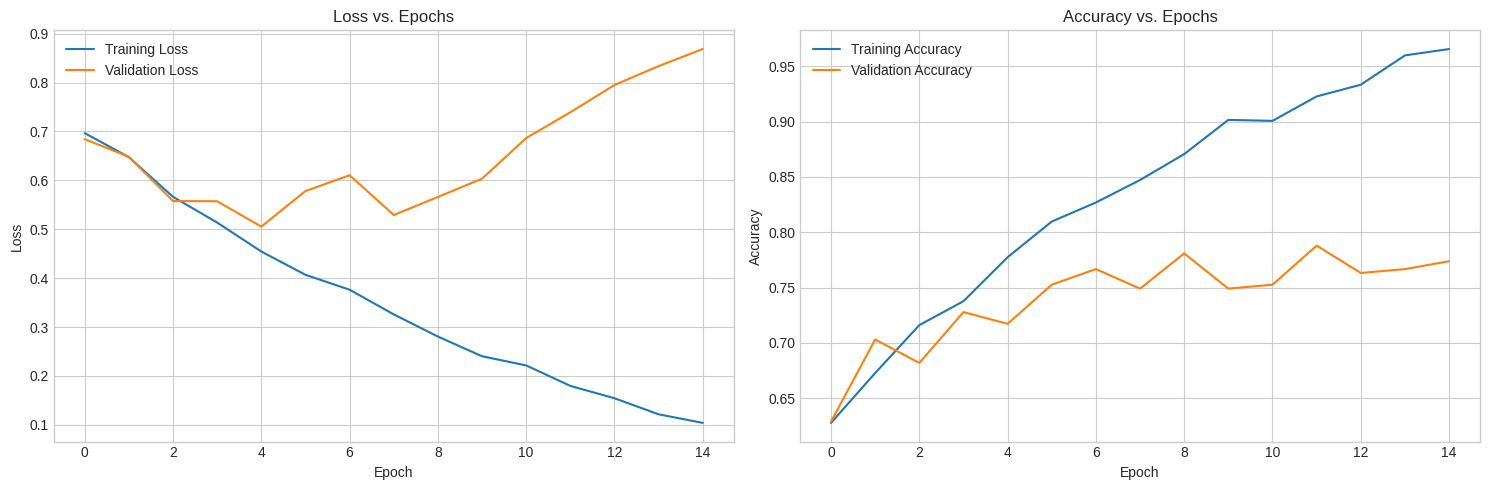

In [ ]:
# Cell 4
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from collections import Counter

# Define the CNN Architecture
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 16 * 16, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 2)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 16 * 16)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Calculate Class Weights
print("Calculating class weights...")
train_labels = [label for _, label in train_list]
class_counts = Counter(train_labels)
weights = [len(train_labels) / (2 * class_counts[i]) for i in range(2)]
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

print(f"Data counts in training set: {class_counts}")
print(f"Calculated weights (for class 0 and 1): {class_weights_tensor.tolist()}")

# Setup for Training
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CustomCNN().to(device)
class_weights_tensor = class_weights_tensor.to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training Loop
NUM_EPOCHS = 50
early_stopping_patience = 10
patience_counter = 0
best_val_loss = float('inf')
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print(f"\n🚀 Starting training on {device.upper()}...")
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss, correct_predictions, total_samples = 0.0, 0, 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Train]"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    history['train_loss'].append(running_loss / total_samples)
    history['train_acc'].append(correct_predictions / total_samples)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_acc'][-1]:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/Modelsss/best_elikec_model.keras')
        print(f"✨ Val loss improved. Saving best model...")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"Val loss did not improve. Patience: {patience_counter}/{early_stopping_patience}")

    if patience_counter >= early_stopping_patience:
        print("\n🛑 Early stopping triggered.")
        break

print("\n✅ Training complete!")

# Visualize Results
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
epochs_ran = len(history['train_loss'])

ax1.plot(range(epochs_ran), history['train_loss'], label='Training Loss')
ax1.plot(range(epochs_ran), history['val_loss'], label='Validation Loss')
ax1.set_title('Loss vs. Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(range(epochs_ran), history['train_acc'], label='Training Accuracy')
ax2.plot(range(epochs_ran), history['val_acc'], label='Validation Accuracy')
ax2.set_title('Accuracy vs. Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

✅ Best model weights loaded for final evaluation.

Running evaluation on the test set...


Testing:   0%|          | 0/9 [00:00<?, ?it/s]


--- Final Test Report ---
              precision    recall  f1-score   support

Normal e (0)       0.95      0.70      0.81       214
e like c (1)       0.49      0.89      0.63        70

    accuracy                           0.75       284
   macro avg       0.72      0.79      0.72       284
weighted avg       0.84      0.75      0.76       284

--- Confusion Matrix ---


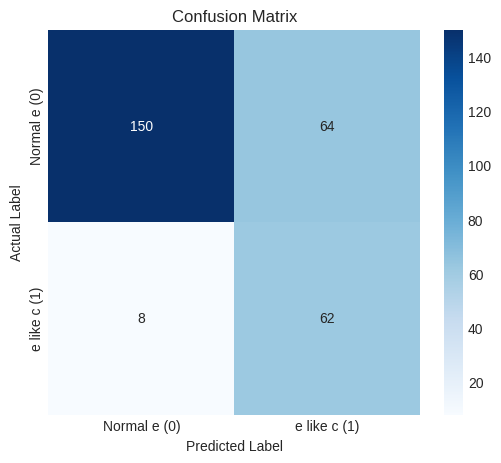

In [ ]:
# Cell 5
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Load the best model weights that we saved during training
model.load_state_dict(torch.load('/content/drive/MyDrive/Modelsss/best_elikec_model.keras'))
print("✅ Best model weights loaded for final evaluation.")

# Set the model to evaluation mode
model.eval()

# Lists to store true labels and model's predictions
y_true = []
y_pred = []

print("\nRunning evaluation on the test set...")
# No need to calculate gradients for evaluation
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.cpu().numpy()) # Save True labels
        y_pred.extend(predicted.cpu().numpy()) # Save Predicted labels

# --- Generate Reports ---
print("\n--- Final Test Report ---")

# 1. Classification Report
class_names = ['Normal e (0)', 'e like c (1)']
print(classification_report(y_true, y_pred, target_names=class_names))

# 2. Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# **D-Height**

In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/d(heighted)_UJIRE_images.xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 'd' classification
label_columns = ['d_tall', 'd_non_tall']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 'd' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 'g'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 'd', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 'd' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
d_tall        660
d_non_tall    464
Name: count, dtype: int64

Scanning for all 'd' images in your Drive... (this may take a moment)
Found 3636 total 'd' images.

Successfully created a final, clean dataset with 1124 labeled images.

Here's a sample of the final data:
                      filename   label  \
0  IMG-20250415-WA0003_200.png  d_tall   
1  IMG-20250415-WA0003_270.png  d_tall   
2  IMG-20250415-WA0003_290.png  d_tall   
3   IMG-20250415-WA0007_10.png  d_tall   
4   IMG-20250415-WA0007_26.png  d_tall   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
1  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
2  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
3  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  
4  /content/drive/MyDrive/extract1_FINAL/s-2021/d...  

✅ Step 2 Complete: Data is loaded and prepar

In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 1124
Training samples:   786
Validation samples: 169
Testing samples:    169

--- Label Distribution Check ---

Training Set:
label
d_tall        0.587786
d_non_tall    0.412214
Name: proportion, dtype: float64

Validation Set:
label
d_tall        0.585799
d_non_tall    0.414201
Name: proportion, dtype: float64

Testing Set:
label
d_tall        0.585799
d_non_tall    0.414201
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 786 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 169 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 169 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: d-loop).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_dheight_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(1.212962962962963), np.int64(1): np.float64(0.8506493506493507)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: d-loop).

--- Starting Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.4893 - loss: 0.7433 
Epoch 1: val_accuracy improved from -inf to 0.41420, saving model to /content/drive/MyDrive/Modelsss/best_dheight_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 743s 30s/step - accuracy: 0.4877 - loss: 0.7422 - val_accuracy: 0.4142 - val_loss: 0.6988
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.4383 - loss: 0.6974
Epoch 2: val_accuracy did not improve from 0.41420
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 139ms/step - accuracy: 0.4377 - loss: 0.6972 - val_accuracy: 0.4142 - val_loss: 0.6936
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.5094 - loss: 0.6922
Epoch 3: val_accuracy improved from 0.41420 to 0.42012, saving model to /content/drive/MyDrive/Modelsss/best_dheight_model.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 187ms/step - accuracy: 0.5101 - loss: 0.6922 - val_accuracy: 0.4201 - val_loss: 0.6937
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.4915 - loss: 0.6953


--- Final Evaluation ---


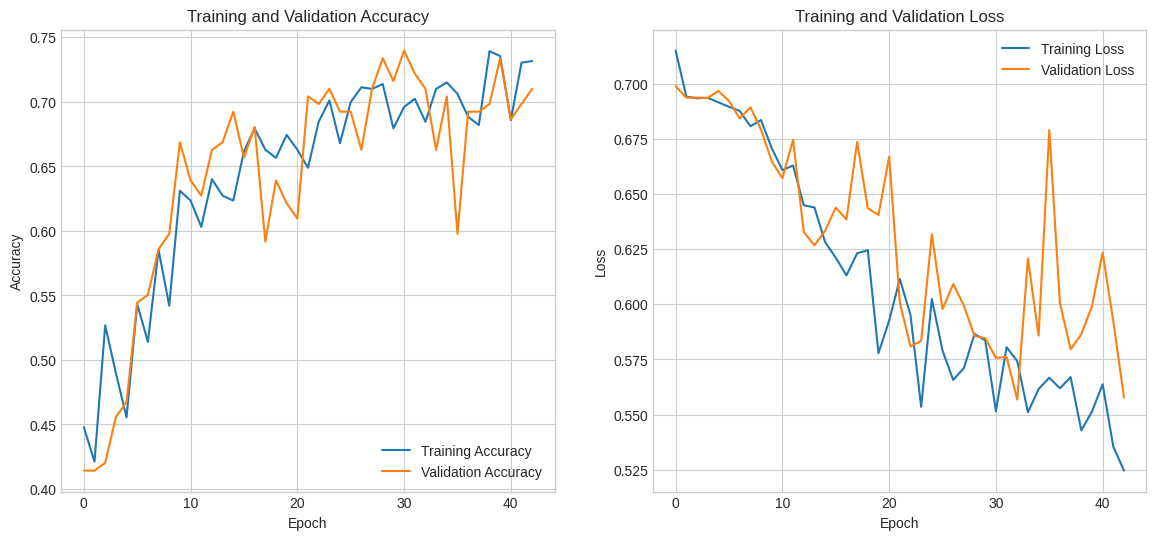


--- Evaluating on Test Data ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 90s 18s/step - accuracy: 0.8074 - loss: 0.4493
Final Test Accuracy: 76.92%
Final Test Loss: 0.4943

--- Detailed Performance Analysis ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 118ms/step

Classification Report:
              precision    recall  f1-score   support

  d_non_tall       0.72      0.71      0.72        70
      d_tall       0.80      0.81      0.80        99

    accuracy                           0.77       169
   macro avg       0.76      0.76      0.76       169
weighted avg       0.77      0.77      0.77       169


Confusion Matrix:


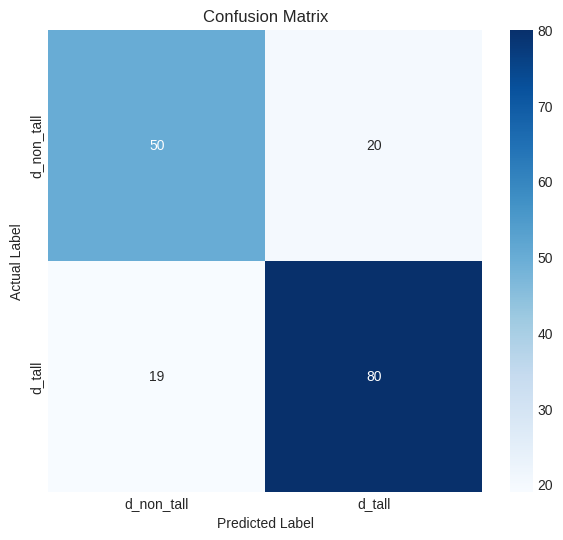


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_dheight_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")

# **T-Tall**

In [ ]:
# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/patient_t_longimages.xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 't' classification
label_columns = ['Long_t', 'Not_long_t']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 't' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 't'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 't', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 't' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
Not_long_t    2765
Long_t         144
Name: count, dtype: int64

Scanning for all 't' images in your Drive... (this may take a moment)
Found 9313 total 't' images.

⚠️ Warning: Could not find 3 files listed in your Excel sheet.
This can happen if filenames in the Excel sheet don't exactly match the image filenames.

Successfully created a final, clean dataset with 2906 labeled images.

Here's a sample of the final data:
                      filename   label  \
0  IMG-20250415-WA0003_249.png  Long_t   
1  IMG-20250415-WA0003_253.png  Long_t   
2  IMG-20250415-WA0003_275.png  Long_t   
3   IMG-20250415-WA0007_44.png  Long_t   
4  IMG-20250415-WA0003_137.png  Long_t   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
1  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  
2  /content/drive/MyDrive/extract1_FINAL/s-2021/t...  


In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 2906
Training samples:   2034
Validation samples: 436
Testing samples:    436

--- Label Distribution Check ---

Training Set:
label
Not_long_t    0.950836
Long_t        0.049164
Name: proportion, dtype: float64

Validation Set:
label
Not_long_t    0.951835
Long_t        0.048165
Name: proportion, dtype: float64

Testing Set:
label
Not_long_t    0.949541
Long_t        0.050459
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 2034 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 436 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 436 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: T_loop).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_ttall_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(10.17), np.int64(1): np.float64(0.5258531540847984)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: T_loop).

--- Starting Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7061 - loss: 0.7332
Epoch 1: val_accuracy improved from -inf to 0.95183, saving model to /content/drive/MyDrive/Modelsss/best_ttall_model.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 275s 4s/step - accuracy: 0.7061 - loss: 0.7328 - val_accuracy: 0.9518 - val_loss: 0.6600
Epoch 2/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8663 - loss: 0.7285
Epoch 2: val_accuracy did not improve from 0.95183
64/64 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.8634 - loss: 0.7280 - val_accuracy: 0.9518 - val_loss: 0.6811
Epoch 3/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9064 - loss: 0.6615
Epoch 3: val_accuracy did not improve from 0.95183
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 156ms/step - accuracy: 0.9035 - loss: 0.6622 - val_accuracy: 0.9518 - val_loss: 0.6241
Epoch 4/50
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.6742 - loss: 0.7275
Epoch 4: val_accuracy did not improve from 0.95183
64/64 ━━━━━━━━━━━━━━━━━━━━ 10s 

--- Final Evaluation ---


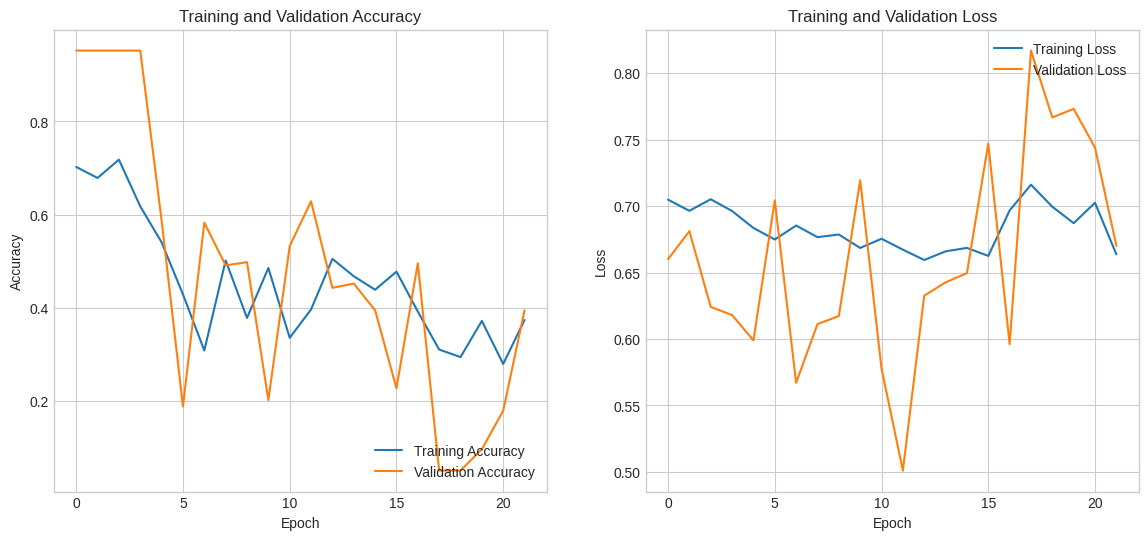


--- Evaluating on Test Data ---
14/14 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.9538 - loss: 0.6601
Final Test Accuracy: 94.95%
Final Test Loss: 0.6607

--- Detailed Performance Analysis ---


14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step

Classification Report:
              precision    recall  f1-score   support

      Long_t       0.00      0.00      0.00        22
  Not_long_t       0.95      1.00      0.97       414

    accuracy                           0.95       436
   macro avg       0.47      0.50      0.49       436
weighted avg       0.90      0.95      0.92       436


Confusion Matrix:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


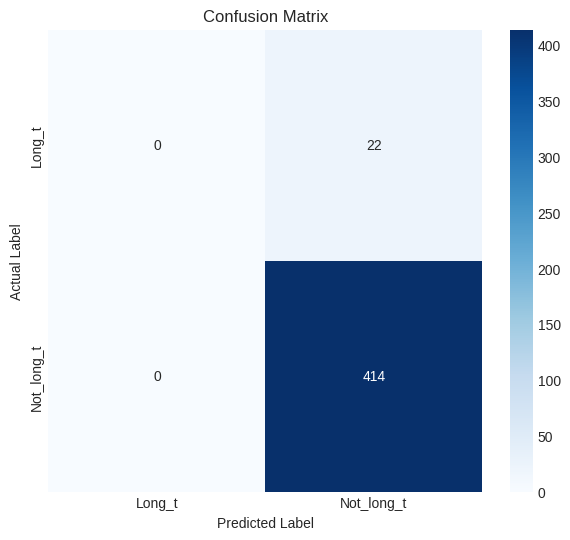


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_ttall_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")

# Y-Loop

In [ ]:
# --- Paths provided by you ---
excel_file_path = '/content/drive/MyDrive/Y_LOOP_UJIRE.xlsx'
main_data_folder = '/content/drive/MyDrive/extract1_FINAL'
# -----------------------------

try:
    df_labels_raw = pd.read_excel(excel_file_path)
    print("✅ Excel file loaded successfully.")
except FileNotFoundError:
    print(f"❌ ERROR: Excel file not found at '{excel_file_path}'. Please double-check the path.")
    assert False, "Halting execution: File not found."

# --- Restructure data from the Excel file ---
all_images = []
# These are the expected column names for 't' classification
label_columns = ['y_loop', 'y_no_loop']

for label in label_columns:
    if label in df_labels_raw.columns:
        # Get all non-empty filenames from the current label column
        filenames = df_labels_raw[label].dropna().astype(str).tolist()
        for fname in filenames:
            all_images.append({'filename': fname.strip(), 'label': label})
    else:
        print(f"⚠️ Warning: Label column '{label}' not found in Excel file.")

# Create a clean DataFrame of labels
df_labels = pd.DataFrame(all_images)

if df_labels.empty:
    print("❌ ERROR: No data was loaded. Check your Excel file path and column names.")
    assert False, "Halting execution: Data loading failed."

print("\nData restructured from Excel. Here is the class distribution:")
print(df_labels['label'].value_counts())

# --- Find all image file paths ---
print("\nScanning for all 'y' images in your Drive... (this may take a moment)")
# This finds all .png files inside any subfolder named 't'
all_image_paths = {os.path.basename(p): p for p in glob.glob(os.path.join(main_data_folder, '**', 'y', '*.png'), recursive=True)}
print(f"Found {len(all_image_paths)} total 'y' images.")

# --- Combine paths and labels ---
df_labels['filepath'] = df_labels['filename'].map(all_image_paths)

# --- Final Cleanup ---
missing_files_count = df_labels['filepath'].isnull().sum()
if missing_files_count > 0:
    print(f"\n⚠️ Warning: Could not find {missing_files_count} files listed in your Excel sheet.")
    print("This can happen if filenames in the Excel sheet don't exactly match the image filenames.")

# Drop rows where the image file wasn't found on Drive
df_final = df_labels.dropna(subset=['filepath'])

print(f"\nSuccessfully created a final, clean dataset with {len(df_final)} labeled images.")
print("\nHere's a sample of the final data:")
print(df_final.head())

print("\n✅ Step 2 Complete: Data is loaded and prepared.")

✅ Excel file loaded successfully.

Data restructured from Excel. Here is the class distribution:
label
y_no_loop    759
y_loop       154
Name: count, dtype: int64

Scanning for all 'y' images in your Drive... (this may take a moment)
Found 2991 total 'y' images.

Successfully created a final, clean dataset with 913 labeled images.

Here's a sample of the final data:
                      filename   label  \
0  IMG-20250415-WA0012_270.png  y_loop   
1   IMG-20250415-WA0021_15.png  y_loop   
2    IMG-20250415-WA0005_8.png  y_loop   
3   IMG-20250415-WA0005_12.png  y_loop   
4   IMG-20250415-WA0005_20.png  y_loop   

                                            filepath  
0  /content/drive/MyDrive/extract1_FINAL/u-2020/y...  
1  /content/drive/MyDrive/extract1_FINAL/t-2005/y...  
2  /content/drive/MyDrive/extract1_FINAL/s-2011/y...  
3  /content/drive/MyDrive/extract1_FINAL/s-2011/y...  
4  /content/drive/MyDrive/extract1_FINAL/s-2011/y...  

✅ Step 2 Complete: Data is loaded and prepared.

In [ ]:
# The DataFrame 'df_final' from the previous step is used here
data_df = df_final

# First, split into training (70%) and a temporary set (30%)
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=42,  # Ensures the split is the same every time
    stratify=data_df['label'] # Crucial for imbalanced data
)

# Now, split the temporary set into validation (15%) and test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,  # 50% of the 30% gives 15% of the total
    random_state=42,
    stratify=temp_df['label']
)

print("Data splitting complete.")
print(f"Total samples: {len(data_df)}")
print(f"Training samples:   {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Testing samples:    {len(test_df)}")

print("\n--- Label Distribution Check ---")
print(f"\nTraining Set:\n{train_df['label'].value_counts(normalize=True)}")
print(f"\nValidation Set:\n{val_df['label'].value_counts(normalize=True)}")
print(f"\nTesting Set:\n{test_df['label'].value_counts(normalize=True)}")

print("\n✅ Step 3 Complete: Data has been split.")

Data splitting complete.
Total samples: 913
Training samples:   639
Validation samples: 137
Testing samples:    137

--- Label Distribution Check ---

Training Set:
label
y_no_loop    0.830986
y_loop       0.169014
Name: proportion, dtype: float64

Validation Set:
label
y_no_loop    0.832117
y_loop       0.167883
Name: proportion, dtype: float64

Testing Set:
label
y_no_loop    0.832117
y_loop       0.167883
Name: proportion, dtype: float64

✅ Step 3 Complete: Data has been split.


In [ ]:
# Define image and batch size parameters
IMG_SIZE = 128  # A size of 128x128 is good for our custom model
BATCH_SIZE = 32

# 1. Define the training data generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Rescale pixel values from [0, 255] to [0, 1]
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
)

# 2. Define the validation/test generator (only rescaling, no augmentation)
validation_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. Create the generators using .flow_from_dataframe()
# The key change is setting color_mode='grayscale'
print("Creating Training Generator...")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=True
)

print("\nCreating Validation Generator...")
validation_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\nCreating Test Generator...")
test_generator = validation_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=(IMG_SIZE, IMG_SIZE),
    class_mode='binary',
    batch_size=BATCH_SIZE,
    color_mode='grayscale', # <-- Key strategic change!
    shuffle=False
)

print("\n✅ Step 4 Complete: Grayscale data generators are ready.")

Creating Training Generator...
Found 639 validated image filenames belonging to 2 classes.

Creating Validation Generator...
Found 137 validated image filenames belonging to 2 classes.

Creating Test Generator...
Found 137 validated image filenames belonging to 2 classes.

✅ Step 4 Complete: Grayscale data generators are ready.


In [ ]:
# Define the input shape for our grayscale images (IMG_SIZE was set to 128)
INPUT_SHAPE = (IMG_SIZE, IMG_SIZE, 1)

# Define our custom model architecture
model = Sequential([
    # Input Layer - specifying the shape of our images
    Input(shape=INPUT_SHAPE),

    # Block 1: Learn basic features like edges and curves
    Conv2D(32, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2: Combine basic features into more complex shapes
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3: Learn even more abstract representations
    Conv2D(128, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D feature maps into a 1D vector to prepare for the classifier
    Flatten(),

    # Classifier Head
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout layer to prevent overfitting
    Dense(1, activation='sigmoid') # Final output layer for binary (0 or 1) classification
])

# Compile the model with an optimizer, loss function, and metric
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the model's architecture
print("--- Custom Model Architecture ---")
model.summary()

print("\n✅ Step 5 Complete: Custom model is built and ready for training.")

--- Custom Model Architecture ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,193 (12.60 MB)

 Trainable params: 3,304,193 (12.60 MB)

 Non-trainable params: 0 (0.00 B)


✅ Step 5 Complete: Custom model is built and ready for training.


In [ ]:
# --- Calculate Class Weights to handle the imbalanced data ---
y_true_classes = train_generator.classes
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_true_classes),
    y=y_true_classes
)
class_weights_dict = dict(zip(np.unique(y_true_classes), class_weights))

print(f"Calculated Class Weights: {class_weights_dict}")
print("The model will be penalized more for misclassifying the class with the higher weight (class 0: Y_loop).")


# --- Define Callbacks for efficient training ---
# 1. Save the best model during training
model_checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/Modelsss/best_yloop_model.keras', # Filepath to save the model
    save_best_only=True,
    monitor='val_accuracy',
    mode='max',
    verbose=1
)

# 2. Stop training if there's no improvement for a while
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10, # Wait 10 epochs for an improvement before stopping
    restore_best_weights=True,
    verbose=1
)


# --- Train the Model ---
# A model trained from scratch needs more time to learn
EPOCHS = 50

print("\n--- Starting Training ---")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    class_weight=class_weights_dict,  # Apply the class weights here
    callbacks=[model_checkpoint, early_stopping]
)

print("\n✅ Step 6 Complete: Model training is finished.")

Calculated Class Weights: {np.int64(0): np.float64(2.9583333333333335), np.int64(1): np.float64(0.6016949152542372)}
The model will be penalized more for misclassifying the class with the higher weight (class 0: Y_loop).

--- Starting Training ---


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - accuracy: 0.5323 - loss: 0.7418 
Epoch 1: val_accuracy improved from -inf to 0.16788, saving model to /content/drive/MyDrive/Modelsss/best_yloop_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 591s 30s/step - accuracy: 0.5361 - loss: 0.7408 - val_accuracy: 0.1679 - val_loss: 0.7026
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3880 - loss: 0.6840
Epoch 2: val_accuracy improved from 0.16788 to 0.21168, saving model to /content/drive/MyDrive/Modelsss/best_yloop_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.3870 - loss: 0.6844 - val_accuracy: 0.2117 - val_loss: 0.7020
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4834 - loss: 0.6706
Epoch 3: val_accuracy improved from 0.21168 to 0.21898, saving model to /content/drive/MyDrive/Modelsss/best_yloop_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.4853 - loss: 0.6715 - val_accuracy: 0.2190 - val_loss: 0.7260
Epoch 4/50
20/

--- Final Evaluation ---


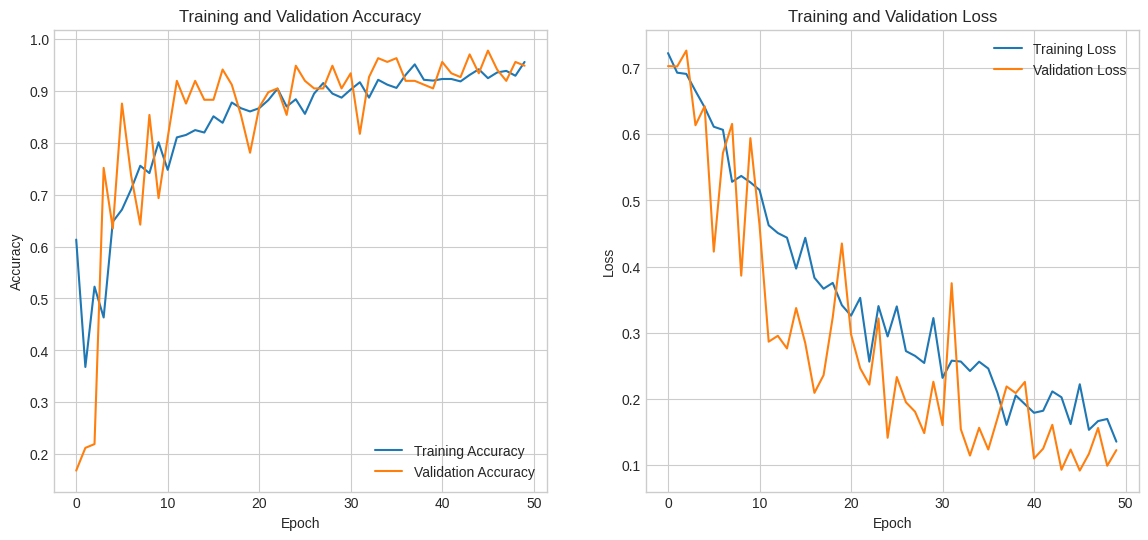


--- Evaluating on Test Data ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 63s 15s/step - accuracy: 0.9249 - loss: 0.2074
Final Test Accuracy: 92.70%
Final Test Loss: 0.1701

--- Detailed Performance Analysis ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step

Classification Report:
              precision    recall  f1-score   support

      y_loop       0.84      0.70      0.76        23
   y_no_loop       0.94      0.97      0.96       114

    accuracy                           0.93       137
   macro avg       0.89      0.83      0.86       137
weighted avg       0.92      0.93      0.92       137


Confusion Matrix:


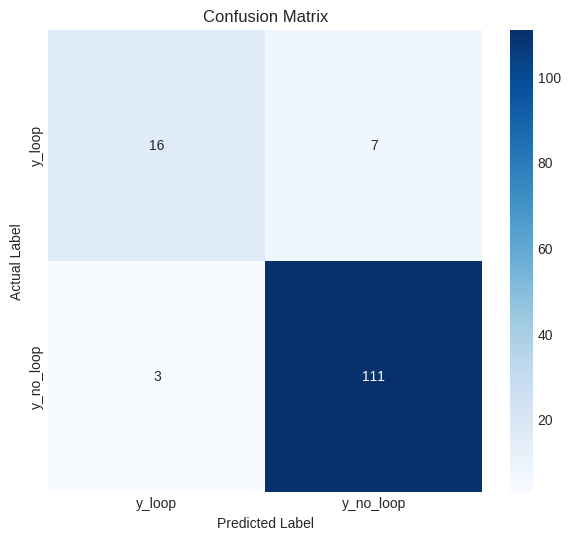


✅ Project Complete: Model has been trained and evaluated.


In [ ]:
print("--- Final Evaluation ---")
# Load the best model saved during training
final_model = tf.keras.models.load_model('/content/drive/MyDrive/Modelsss/best_yloop_model.keras')

# --- 1. Plot Training History ---
# The 'history' object holds the training logs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


# --- 2. Evaluate on the Unseen Test Set ---
print("\n--- Evaluating on Test Data ---")
loss, accuracy = final_model.evaluate(test_generator)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")
print(f"Final Test Loss: {loss:.4f}")


# --- 3. Generate Detailed Reports ---
print("\n--- Detailed Performance Analysis ---")
# Get the true labels from the test generator
y_true = test_generator.classes
# Make predictions on the test data
predictions = final_model.predict(test_generator)
# Convert the prediction probabilities to class labels (0 or 1)
y_pred = (predictions > 0.5).astype(int).reshape(-1)

# Get the names of the classes
class_names = list(test_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

print("\n✅ Project Complete: Model has been trained and evaluated.")